Women's E-Commerce Clothing Reviews
https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews
Це датасет з відгуками клієнтів інтернет-магазину.

Дослідницький аналіз даних перед побудовою моделей для передбачення `Recommended IND` (чи рекомендує клієнт товар).
Опис полів
- Clothing ID - числова категоріальна змінна, що
ідентифікує конкретний товар, на який написано відгук.
- Age - вік рецензента (ціле позитивне число).
- Title - заголовок відгуку (текстове поле).
- Review Text - основний текст відгуку (текстове поле).
- Rating - оцінка товару від клієнта за шкалою від 1 (найгірше) до 5 (найкраще).
- Recommended IND - бінарна змінна: 1 - клієнт рекомендує товар, 0 - не рекомендує.
- Positive Feedback Count - кількість інших клієнтів, які відзначили цей відгук як корисний.
- Division Name - назва верхньорівневого підрозділу (категорії) товару.
- Department Name - назва департаменту товару.
- Class Name - назва класу товару.

## 1. Імпорт бібліотек

In [ ]:
!pip install optuna -q
!pip install transformers torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import lightgbm as lgb
import optuna
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import random
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)

## 2. Завантаження даних

In [ ]:
df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv', index_col=0)
print("Розмір датасету:", df.shape)
df.head()


Розмір датасету: (23486, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 3. Загальна інформація про колонки

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


In [ ]:
df.describe()


,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


## 4. Пропущені значення

In [ ]:
missing_count = df.isna().sum()
missing_pct = missing_count / len(df) * 100
print(missing_count)


Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


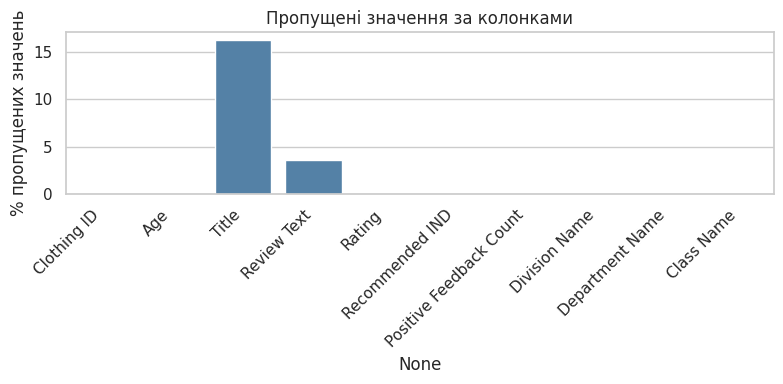

In [ ]:
# пропущені значення по колонках
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_pct.index, y=missing_pct.values, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("% пропущених значень")
plt.title("Пропущені значення за колонками")
plt.tight_layout()
plt.show()


## 5. Розподіл цільової змінної Recommended IND

In [ ]:
target_counts = df["Recommended IND"].value_counts()
print(target_counts)


Recommended IND
1    19314
0     4172
Name: count, dtype: int64


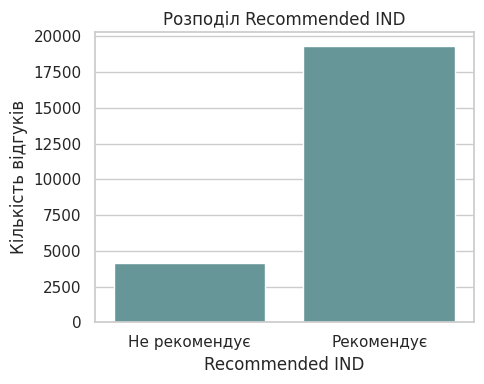

In [ ]:
# баланс класів
plt.figure(figsize=(5, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, color="cadetblue")
plt.xticks([0, 1], ["Не рекомендує", "Рекомендує"])
plt.ylabel("Кількість відгуків")
plt.title("Розподіл Recommended IND")
plt.tight_layout()
plt.show()


## 6. Розподіл Rating та зв'язок з Recommended IND

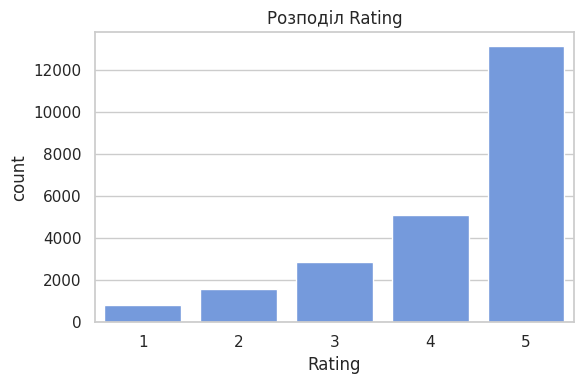

In [ ]:
# розподіл рейтингів
plt.figure(figsize=(6, 4))
sns.countplot(x="Rating", data=df, color="cornflowerblue")
plt.title("Розподіл Rating")
plt.tight_layout()
plt.show()


Rating
1    0.019002
2    0.060064
3    0.414141
4    0.966910
5    0.998096
Name: Recommended IND, dtype: float64


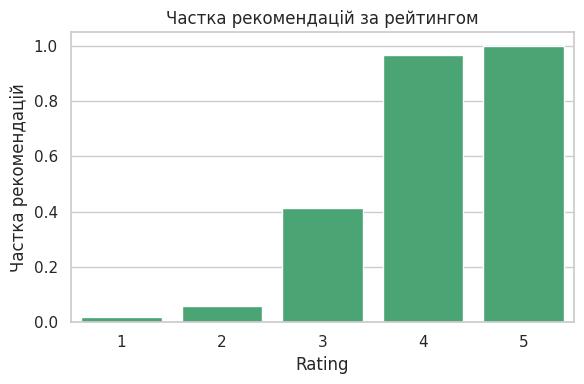

In [ ]:
# частка рекомендацій за кожним рейтингом
rating_recommend = df.groupby("Rating")["Recommended IND"].mean()
print(rating_recommend)

plt.figure(figsize=(6, 4))
sns.barplot(x=rating_recommend.index, y=rating_recommend.values, color="mediumseagreen")
plt.ylabel("Частка рекомендацій")
plt.title("Частка рекомендацій за рейтингом")
plt.tight_layout()
plt.show()


## 7. Розподіл віку клієнтів

In [ ]:
print(df["Age"].describe())


count    23486.000000
mean        43.198544
std         12.279544
min         18.000000
25%         34.000000
50%         41.000000
75%         52.000000
max         99.000000
Name: Age, dtype: float64


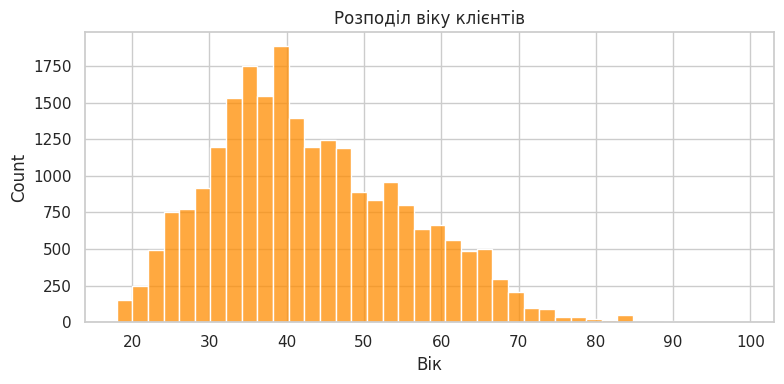

In [ ]:
# розподіл віку
plt.figure(figsize=(8, 4))
sns.histplot(df["Age"], bins=40, color="darkorange")
plt.title("Розподіл віку клієнтів")
plt.xlabel("Вік")
plt.tight_layout()
plt.show()


## 8. Довжина тексту відгуку

In [ ]:
df["review_text_filled"] = df["Review Text"].fillna("")
df["review_word_count"] = df["review_text_filled"].str.split().str.len()

print(df["review_word_count"].describe())


count    23486.000000
mean        58.030869
std         30.176433
min          0.000000
25%         34.000000
50%         57.000000
75%         87.000000
max        115.000000
Name: review_word_count, dtype: float64


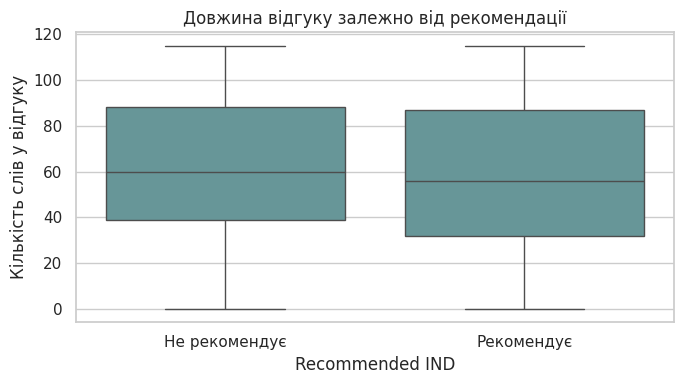

In [ ]:
# довжина відгуку за класами Recommended IND
plt.figure(figsize=(7, 4))
sns.boxplot(x="Recommended IND", y="review_word_count", data=df, color="cadetblue")
plt.xticks([0, 1], ["Не рекомендує", "Рекомендує"])
plt.ylabel("Кількість слів у відгуку")
plt.title("Довжина відгуку залежно від рекомендації")
plt.tight_layout()
plt.show()


## 9. Категорії товарів (Department Name)

In [ ]:
department_counts = df["Department Name"].value_counts()
print(department_counts)


Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
Name: count, dtype: int64


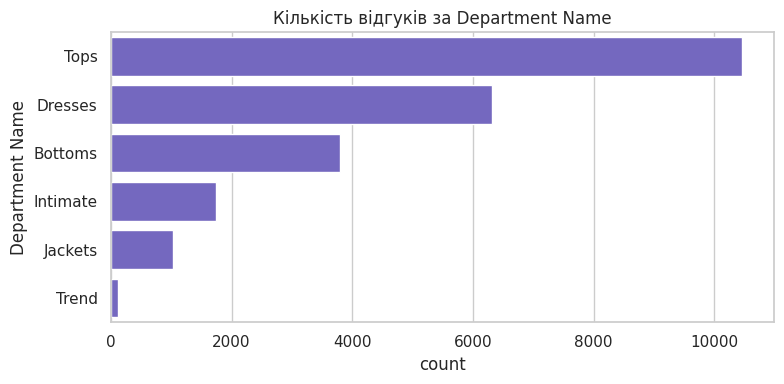

In [ ]:
# кількість відгуків за категорією товару
plt.figure(figsize=(8, 4))
sns.countplot(y="Department Name", data=df, order=department_counts.index, color="slateblue")
plt.title("Кількість відгуків за Department Name")
plt.tight_layout()
plt.show()


Department Name
Trend       0.739496
Dresses     0.808197
Tops        0.815151
Jackets     0.836240
Intimate    0.850144
Bottoms     0.851277
Name: Recommended IND, dtype: float64


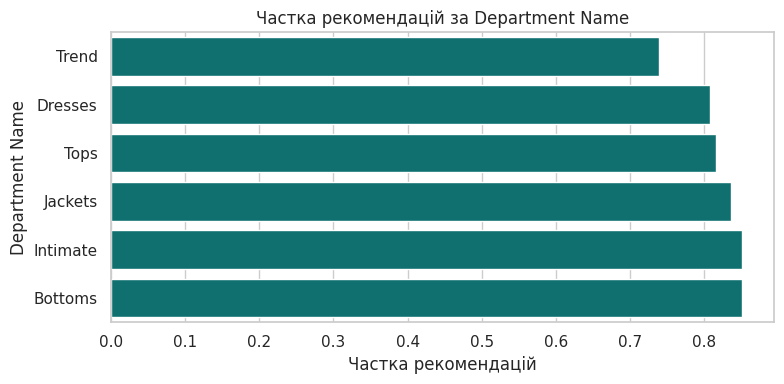

In [ ]:
# частка рекомендацій за категорією товару
department_recommend = df.groupby("Department Name")["Recommended IND"].mean().sort_values()
print(department_recommend)

plt.figure(figsize=(8, 4))
sns.barplot(x=department_recommend.values, y=department_recommend.index, color="teal")
plt.xlabel("Частка рекомендацій")
plt.title("Частка рекомендацій за Department Name")
plt.tight_layout()
plt.show()


## 10. Positive Feedback Count

In [ ]:
df["Positive Feedback Count"].value_counts().sort_index()

,count
Positive Feedback Count,
0,11176
1,4043
2,2193
3,1433
4,922
...,...
98,1
99,1
108,1


In [ ]:
print(df["Positive Feedback Count"].describe())

count    23486.000000
mean         2.535936
std          5.702202
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        122.000000
Name: Positive Feedback Count, dtype: float64


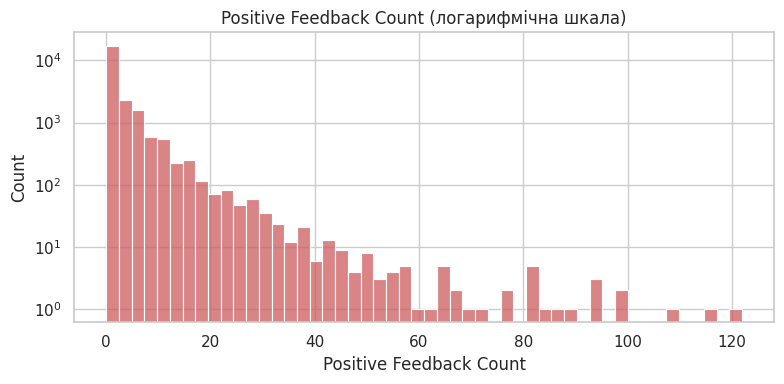

In [ ]:
# розподіл Positive Feedback Count
plt.figure(figsize=(8, 4))
sns.histplot(df["Positive Feedback Count"], bins=50, color="indianred")
plt.yscale("log")
plt.title("Positive Feedback Count (логарифмічна шкала)")
plt.tight_layout()
plt.show()


## 11. Розподіл відгуків по товарам

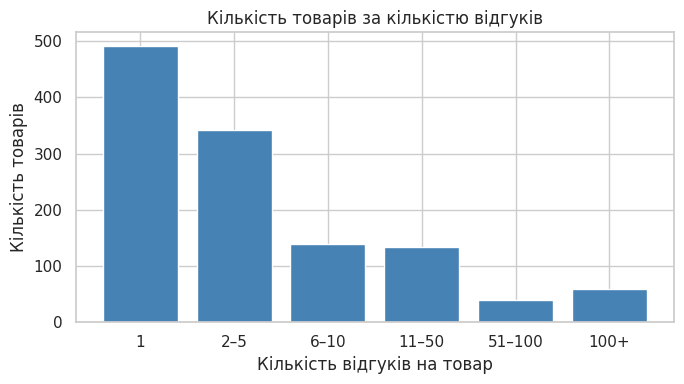

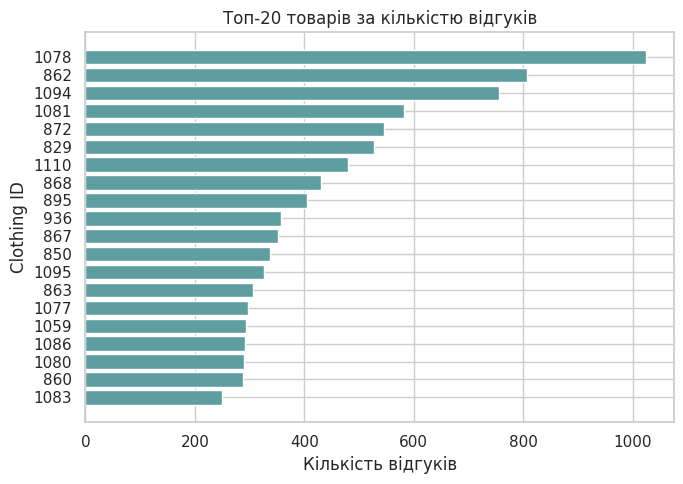

In [ ]:
#  Кількість відгуків на кожен товар
reviews_per_item = df["Clothing ID"].value_counts()

#  Групування товарів
bins = [1, 2, 5, 10, 50, 100, reviews_per_item.max() + 1]
labels = ["1", "2–5", "6–10", "11–50", "51–100", "100+"]
groups = pd.cut(reviews_per_item, bins=bins, labels=labels, right=False)
group_counts = groups.value_counts().reindex(labels)

#  кількість товарів за групами відгуків
plt.figure(figsize=(7, 4))
plt.bar(group_counts.index, group_counts.values, color="steelblue")
plt.title("Кількість товарів за кількістю відгуків")
plt.xlabel("Кількість відгуків на товар")
plt.ylabel("Кількість товарів")
plt.tight_layout()
plt.show()

#  топ-20 товарів за кількістю відгуків
top20 = reviews_per_item.head(20)

plt.figure(figsize=(7, 5))
plt.barh(top20.index.astype(str), top20.values, color="cadetblue")
plt.gca().invert_yaxis()
plt.title("Топ-20 товарів за кількістю відгуків")
plt.xlabel("Кількість відгуків")
plt.ylabel("Clothing ID")
plt.tight_layout()
plt.show()


## 12. Викиди у числових ознаках

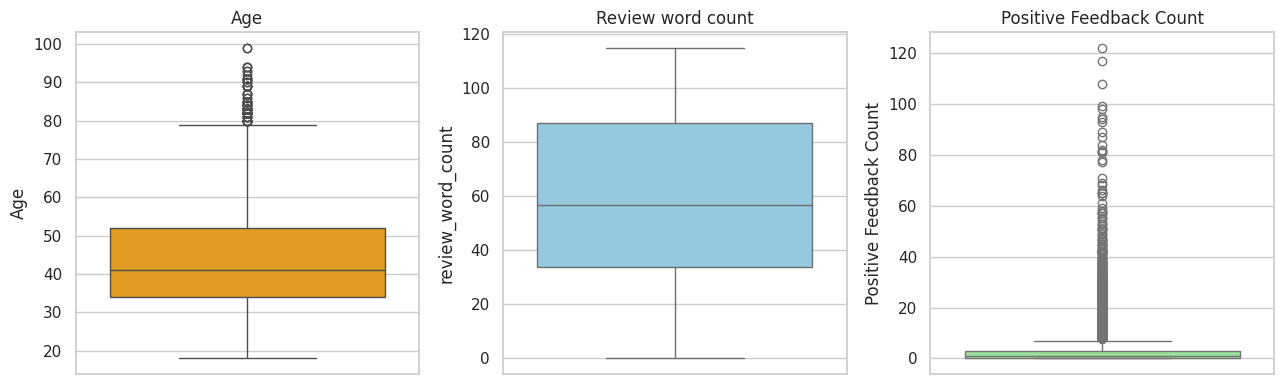

In [ ]:
# boxplots для пошуку викидів
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sns.boxplot(y=df["Age"], ax=axes[0], color="orange")
axes[0].set_title("Age")
sns.boxplot(y=df["review_word_count"], ax=axes[1], color="skyblue")
axes[1].set_title("Review word count")
sns.boxplot(y=df["Positive Feedback Count"], ax=axes[2], color="lightgreen")
axes[2].set_title("Positive Feedback Count")
plt.tight_layout()
plt.show()


## 13. Кореляція числових ознак

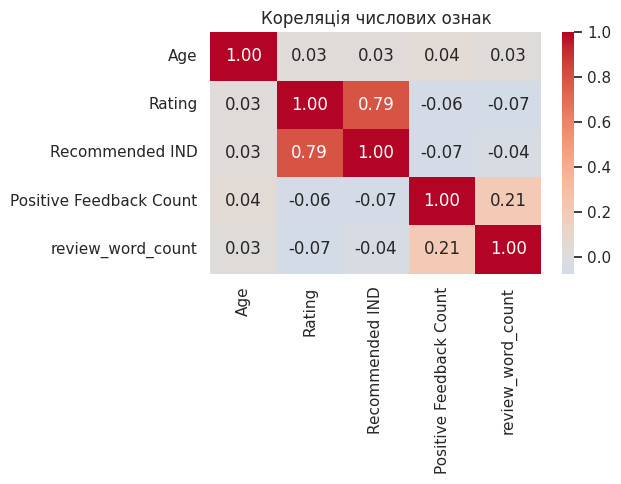

In [ ]:
# матриця кореляцій
numeric_cols = ["Age", "Rating", "Recommended IND", "Positive Feedback Count", "review_word_count"]

plt.figure(figsize=(6.5, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Кореляція числових ознак")
plt.tight_layout()
plt.show()


#висновок  по EDA


1. помітний сильний зв'язок Rating з цільовою змінною, тому для подальшої роботи стовпець Rating буде видалено, щоб модель не почала в якийсь момент ігнорувати текстовий відгук і орієнтуватись лише на рейтинг.
2. Title містить забагато NAN - поле можна видалити.
3. вік має викиди після 75 які можна замінити медіаною, або створити категоріальну зміну сегмента віку - для себе обираю створення сегментів, бо вважаю це більш сильною категоріальною фічею для еком даних.
4. Довжну відгуку можна зробити додатковою фічею
4. в Division Name, Department Name, Class Name є  14 пропусків, оскільки це дуже маленький % від загальної кід-ті записів, то ці рядки можна видалити
5. Clothing ID - формально числовий, але це ідентифікатор товару, а не змістовне число. Якщо одного товару багато відгуків - можна зробити агреговану ознаку "середній рейтинг по товару" але в нашому випадку на графіках видно, що 878 з 1206 товарів мають ≤5 відгуків, тому така фіча не буде стат надійною для всього датасету. Стовпець видаляємо для подальшої роботи.
6. Дисбаланс класів - з графіка видно, що клас "рекомендує" (1) значно переважає над "не рекомендує" (0). Це означає, що accuracy буде оманливою метрикою - варто використовувати F1-score або ROC-AUC
7. Positive Feedback Count має дуже скошений розподіл (більшість значень - 0 або близько до нуля, є одиничні викиди). Перед використанням як ознаки варто застосувати логарифмічне перетворення: log(x + 1).


# Preprocessing

In [ ]:
#видалимо стовпець Rating, Title, Clothing ID
df = df.drop(columns=["Rating", "Title", "Clothing ID"])

In [ ]:
# видалимо рядки де є nan в Division Name, Department Name, Class Name
df = df.dropna(subset=["Division Name", "Department Name", "Class Name"])

In [ ]:
# створення сегментів для віку
bins = [0, 30, 45, 60, 100]
labels = ["18–30", "31–45", "46–60", "60+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [ ]:
df = df.drop(columns=["Age"])

In [ ]:
# логарифмування Positive Feedback Count
df["Positive Feedback Count"] = np.log1p(df["Positive Feedback Count"])

In [ ]:
# видадяємо рядки з порожніми текстовими відгуками, оскільки вони створять шум для моделі
df = df.dropna(subset=["Review Text"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22628 entries, 0 to 23485
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Review Text              22628 non-null  object  
 1   Recommended IND          22628 non-null  int64   
 2   Positive Feedback Count  22628 non-null  float64 
 3   Division Name            22628 non-null  object  
 4   Department Name          22628 non-null  object  
 5   Class Name               22628 non-null  object  
 6   review_text_filled       22628 non-null  object  
 7   review_word_count        22628 non-null  int64   
 8   Age Group                22628 non-null  category
dtypes: category(1), float64(1), int64(2), object(5)
memory usage: 1.6+ MB


# Baseline (Logistic Regression + TF-IDF)

### test_train_val

In [ ]:
X = df["Review Text"]
y = df["Recommended IND"]

# test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# потім з решти відділяємо validation (20% від train_val = 16% від усіх)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print("Train:", X_train.shape[0])
print("Validation:", X_val.shape[0])
print("Test:", X_test.shape[0])

Train: 14481
Validation: 3621
Test: 4526


### TF-IDF

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Розмір train матриці:", X_train_tfidf.shape)

Розмір train матриці: (14481, 5000)


## LogisticRegression

### with stop words

In [ ]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train_tfidf, y_train)

# передбачення
y_val_pred = lr.predict(X_val_tfidf)
y_val_proba = lr.predict_proba(X_val_tfidf)[:, 1]

# метрики
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)

print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

F1-score:  0.9223
ROC-AUC:   0.9430


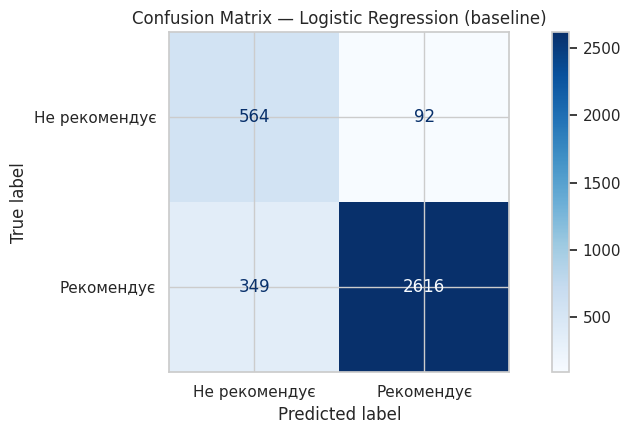

In [ ]:
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Не рекомендує", "Рекомендує"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression (baseline)")
plt.tight_layout()
plt.show()

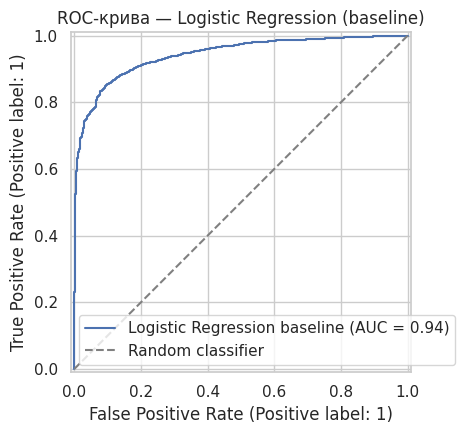

In [ ]:
RocCurveDisplay.from_predictions(y_val, y_val_proba, name="Logistic Regression baseline")
plt.title("ROC-крива — Logistic Regression (baseline)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.legend()
plt.tight_layout()
plt.show()

###without standart stop words

In [ ]:
tfidf_sw = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")

X_train_tfidf_sw = tfidf_sw.fit_transform(X_train)
X_val_tfidf_sw = tfidf_sw.transform(X_val)

lr_sw = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_sw.fit(X_train_tfidf_sw, y_train)

y_val_pred_sw = lr_sw.predict(X_val_tfidf_sw)
y_val_proba_sw = lr_sw.predict_proba(X_val_tfidf_sw)[:, 1]

f1_sw = f1_score(y_val, y_val_pred_sw)
roc_auc_sw = roc_auc_score(y_val, y_val_proba_sw)

print(f"F1-score:  {f1_sw:.4f}")
print(f"ROC-AUC:   {roc_auc_sw:.4f}")

F1-score:  0.9142
ROC-AUC:   0.9312


###without custom stop words

In [ ]:
custom_stop_words = list(ENGLISH_STOP_WORDS - {"not", "no", "never"})

tfidf_csw = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words=custom_stop_words)

X_train_tfidf_csw = tfidf_csw.fit_transform(X_train)
X_val_tfidf_csw = tfidf_csw.transform(X_val)

lr_csw = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_csw.fit(X_train_tfidf_csw, y_train)

y_val_pred_csw = lr_csw.predict(X_val_tfidf_csw)
y_val_proba_csw = lr_csw.predict_proba(X_val_tfidf_csw)[:, 1]

f1_csw = f1_score(y_val, y_val_pred_csw)
roc_auc_csw = roc_auc_score(y_val, y_val_proba_csw)

print(f"F1-score:  {f1_csw:.4f}")
print(f"ROC-AUC:   {roc_auc_csw:.4f}")

F1-score:  0.9194
ROC-AUC:   0.9357


In [ ]:
results = pd.DataFrame({
    "Модель": [
        "LR — with stop words",
        "LR — without english stop_words",
        "LR — without custom stop_words"
    ],
    "F1-score": [round(f1, 4), round(f1_sw, 4), round(f1_csw, 4)],
    "ROC-AUC": [round(roc_auc, 4), round(roc_auc_sw, 4), round(roc_auc_csw, 4)]
})

results

,Модель,F1-score,ROC-AUC
0,LR — with stop words,0.9223,0.9430
1,LR — without english stop_words,0.9142,0.9312
2,LR — without custom stop_words,0.9194,0.9357


### на даному етапі фіксуємо baseline = LR - with stop words (val F1: 0.9223)

In [ ]:
cat_cols = ["Division Name", "Department Name", "Class Name", "Age Group"]

# числові + категоріальні ознаки
tab_cols = ["Positive Feedback Count", "review_word_count",
            "Division Name", "Department Name", "Class Name", "Age Group"]

# split на train/val/test
X_text = df["Review Text"].fillna("")
X_tab = df[tab_cols].copy()
y = df["Recommended IND"]

X_text_train, X_text_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_text, X_tab, y, test_size=0.2, random_state=42, stratify=y
)

X_text_train, X_text_val, X_tab_train, X_tab_val, y_train, y_val = train_test_split(
    X_text_train, X_tab_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# кодуємо категоріальні колонки
for col in cat_cols:
    le = LabelEncoder()
    X_tab_train[col] = le.fit_transform(X_tab_train[col].astype(str))

    known_classes = set(le.classes_)

    X_tab_val[col] = X_tab_val[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in known_classes else -1
    )
    X_tab_test[col] = X_tab_test[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in known_classes else -1
    )

In [ ]:
# окремий TF-IDF vectorizer для LGBM
tfidf_lgb = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf_lgb = tfidf_lgb.fit_transform(X_text_train)
X_val_tfidf_lgb = tfidf_lgb.transform(X_text_val)
X_test_tfidf_lgb = tfidf_lgb.transform(X_text_test)

# табличні ознаки у sparse формат
X_train_tab = csr_matrix(X_tab_train.values)
X_val_tab = csr_matrix(X_tab_val.values)
X_test_tab = csr_matrix(X_tab_test.values)

# об'єднуємо TF-IDF + табличні ознаки
X_train_lgb = hstack([X_train_tfidf_lgb, X_train_tab])
X_val_lgb = hstack([X_val_tfidf_lgb, X_val_tab])
X_test_lgb = hstack([X_test_tfidf_lgb, X_test_tab])

print("Розмір train матриці:", X_train_lgb.shape)

Розмір train матриці: (14481, 5006)


In [ ]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# передбачення базового LGBM
y_val_pred_lgb_base = lgb_model.predict(X_val_lgb)
y_val_proba_lgb_base = lgb_model.predict_proba(X_val_lgb)[:, 1]

# метрики
f1_lgb = f1_score(y_val, y_val_pred_lgb_base)
roc_auc_lgb = roc_auc_score(y_val, y_val_proba_lgb_base)

print(f"F1-score:  {f1_lgb:.4f}")
print(f"ROC-AUC:   {roc_auc_lgb:.4f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.414217
[200]	valid_0's binary_logloss: 0.358396
[300]	valid_0's binary_logloss: 0.327868
[400]	valid_0's binary_logloss: 0.309691
[500]	valid_0's binary_logloss: 0.297564
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.297564
F1-score:  0.9184
ROC-AUC:   0.9279


In [ ]:
results_2 = pd.DataFrame({
    "Модель": [
        "LR — with stop words",
        "LGBM — with stop words"

    ],
    "F1-score": [round(f1, 4), round(f1_lgb, 4)],
    "ROC-AUC": [round(roc_auc, 4),round(roc_auc_lgb, 4)]
})

results_2

,Модель,F1-score,ROC-AUC
0,LR — with stop words,0.9223,0.9430
1,LGBM — with stop words,0.9184,0.9279


In [ ]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "class_weight": "balanced",
        "random_state": 42,
        "verbose": -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_lgb, y_train)

    y_pred = model.predict(X_val_lgb)
    return f1_score(y_val, y_pred)


optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=30)

print("Найкращі параметри:", study.best_params)
print("Найкращий F1-score:", round(study.best_value, 4))

Найкращі параметри: {'n_estimators': 863, 'learning_rate': 0.2475295391080053, 'max_depth': 9, 'num_leaves': 80, 'min_child_samples': 41}
Найкращий F1-score: 0.9359


In [ ]:
best_lgb = lgb.LGBMClassifier(
    n_estimators=995,
    learning_rate=0.12203284200088314,
    max_depth=8,
    num_leaves=86,
    min_child_samples=24,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

best_lgb.fit(X_train_lgb, y_train)

# передбачення тюнингованого LGBM - окремі назви змінних
y_val_pred_lgb_best = best_lgb.predict(X_val_lgb)
y_val_proba_lgb_best = best_lgb.predict_proba(X_val_lgb)[:, 1]

f1_lgb_best = f1_score(y_val, y_val_pred_lgb_best)
roc_auc_lgb_best = roc_auc_score(y_val, y_val_proba_lgb_best)

print(f"F1-score:  {f1_lgb_best:.4f}")
print(f"ROC-AUC:   {roc_auc_lgb_best:.4f}")

F1-score:  0.9329
ROC-AUC:   0.9314


In [ ]:
results_3 = pd.DataFrame({
    "Модель": [
        "LR — with stop words",
        "LGBM — with stop words",
        "LGBM — with stop words best parametrs"

    ],
    "F1-score": [round(f1, 4), round(f1_lgb, 4), round(f1_lgb_best, 4)],
    "ROC-AUC": [round(roc_auc, 4),round(roc_auc_lgb, 4),round(roc_auc_lgb_best, 4)]
})

results_3

,Модель,F1-score,ROC-AUC
0,LR — with stop words,0.9223,0.9430
1,LGBM — with stop words,0.9184,0.9279
2,LGBM — with stop words best parametrs,0.9329,0.9314


# Neural Network з Embedding шаром

In [ ]:
MAX_WORDS = 10000  # розмір словника
MAX_LEN = 100      # максимальна довжина відгуку у словах

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_text_train)

X_train_seq = tokenizer.texts_to_sequences(X_text_train)
X_val_seq = tokenizer.texts_to_sequences(X_text_val)
X_test_seq = tokenizer.texts_to_sequences(X_text_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Розмір train:", X_train_pad.shape)
print("Розмір val:  ", X_val_pad.shape)

Розмір train: (14481, 100)
Розмір val:   (3621, 100)


In [ ]:
model_nn = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_nn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop]
)

Epoch 1/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8326 - loss: 0.4056 - val_accuracy: 0.8680 - val_loss: 0.2960
Epoch 2/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8910 - loss: 0.2554 - val_accuracy: 0.8268 - val_loss: 0.3471
Epoch 3/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9102 - loss: 0.2206 - val_accuracy: 0.8291 - val_loss: 0.3417
Epoch 4/10
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9231 - loss: 0.1947 - val_accuracy: 0.8357 - val_loss: 0.3462


In [ ]:
y_val_proba_nn = model_nn.predict(X_val_pad).flatten()
y_val_pred_nn = (y_val_proba_nn >= 0.5).astype(int)

f1_nn = f1_score(y_val, y_val_pred_nn)
roc_auc_nn = roc_auc_score(y_val, y_val_proba_nn)

print(f"F1-score:  {f1_nn:.4f}")
print(f"ROC-AUC:   {roc_auc_nn:.4f}")

114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
F1-score:  0.9184
ROC-AUC:   0.9033


In [ ]:
results_4 = pd.DataFrame({
    "Модель": [
        "LR — with stop words",
        "LGBM — with stop words",
        "LGBM — with stop words best parametrs",
        "Neural Network з Embedding"
    ],
    "F1-score": [round(f1, 4), round(f1_lgb, 4), round(f1_lgb_best, 4), round(f1_nn, 4)],
    "ROC-AUC": [round(roc_auc, 4),round(roc_auc_lgb, 4),round(roc_auc_lgb_best, 4),round(roc_auc_nn, 4)]
})

results_4

,Модель,F1-score,ROC-AUC
0,LR — with stop words,0.9223,0.9430
1,LGBM — with stop words,0.9184,0.9279
2,LGBM — with stop words best parametrs,0.9329,0.9314
3,Neural Network з Embedding,0.9184,0.9033


##DistilBERT

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer_bert = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
model_bert = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)

print("Модель завантажена на:", device)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель завантажена на: cuda


In [ ]:
MAX_LEN = 100

train_encodings = tokenizer_bert(
    list(X_text_train),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

val_encodings = tokenizer_bert(
    list(X_text_val),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

test_encodings = tokenizer_bert(
    list(X_text_test),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

print("Приклад токенізації:")
print(train_encodings["input_ids"][0])

Приклад токенізації:
tensor([  101,  2023,  2003,  1037,  2307,  2210,  2327,  1012,  6087,  2024,
         3376,  1998,  2062, 17026,  1999,  2613,  2166,  1012,  3641,  2946,
         2312,  1998,  1996,  4906,  2003,  1996,  2168,  2004,  1996,  2944,
         1012,  2017,  2071,  2763,  2946,  2091,  1012,  2849, 19990,  2024,
         1037,  2978,  2312,  2021,  2572,  4060,  2100,  2055,  2008,  2181,
         1998,  1045,  2064,  2147,  2007,  2009,  1012,  1996,  2303,  6223,
         2021,  2009,  1005,  1055,  2025,  4121,  1998,  2003, 11754,  6562,
         1012,  1996,  2152,  3300,  1998,  5495,  2024,  9548,  1012,  2097,
         2022, 10140,  2104,  1037, 14329,  2030,  6598,  2004,  4633,  4658,
         2015,  1012,  2204,  4965,  2006,  5096,  1012,   102,     0,     0])


In [ ]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = ReviewDataset(train_encodings, list(y_train))
val_dataset = ReviewDataset(val_encodings, list(y_val))
test_dataset = ReviewDataset(test_encodings, list(y_test))

print("Train:", len(train_dataset))
print("Val:  ", len(val_dataset))
print("Test: ", len(test_dataset))

Train: 14481
Val:   3621
Test:  4526


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)

    f1 = f1_score(labels, preds)
    roc_auc = roc_auc_score(labels, probs)

    return {"f1": f1, "roc_auc": roc_auc}


training_args = TrainingArguments(
    output_dir="./distilbert_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=50,
)

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1,Roc Auc
1,0.197094,0.285045,0.944272,0.954060
2,0.122936,0.292478,0.945992,0.954667
3,0.061131,0.363028,0.947368,0.956763


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2718, training_loss=0.16537358516976622, metrics={'train_runtime': 429.4536, 'train_samples_per_second': 101.159, 'train_steps_per_second': 6.329, 'total_flos': 1123980703088400.0, 'train_loss': 0.16537358516976622, 'epoch': 3.0})

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

Training Loss,Validation Loss,Epoch,F1,Roc Auc
0.061131,0.363028,3,0.947368,0.956763


{'eval_loss': 0.36302801966667175, 'eval_f1': 0.9473684210526315, 'eval_roc_auc': 0.9567630999876608}


In [ ]:
results_5 = pd.DataFrame({
    "Модель": [
        "LR — with stop words",
        "LGBM — with stop words",
        "LGBM — with stop words best parametrs",
        "Neural Network з Embedding",
        "DistilBERT"
    ],
    "F1-score": [
        round(f1, 4),
        round(f1_lgb, 4),
        round(f1_lgb_best, 4),
        round(f1_nn, 4),
        round(eval_results["eval_f1"], 4)
    ],
    "ROC-AUC": [
        round(roc_auc, 4),
        round(roc_auc_lgb, 4),
        round(roc_auc_lgb_best, 4),
        round(roc_auc_nn, 4),
        round(eval_results["eval_roc_auc"], 4)
    ]
})

results_5

,Модель,F1-score,ROC-AUC
0,LR — with stop words,0.9223,0.9430
1,LGBM — with stop words,0.9184,0.9279
2,LGBM — with stop words best parametrs,0.9329,0.9314
3,Neural Network з Embedding,0.9184,0.9033
4,DistilBERT,0.9474,0.9568


###перевірка на test DistilBERT

In [ ]:
test_results = trainer.evaluate(test_dataset)
f1_test_bert = test_results["eval_f1"]
roc_auc_test_bert = test_results["eval_roc_auc"]



Training Loss,Validation Loss,Epoch,F1,Roc Auc
0.061131,0.381342,3,0.942173,0.952595


###Confusion Matrix для DistilBERT на test

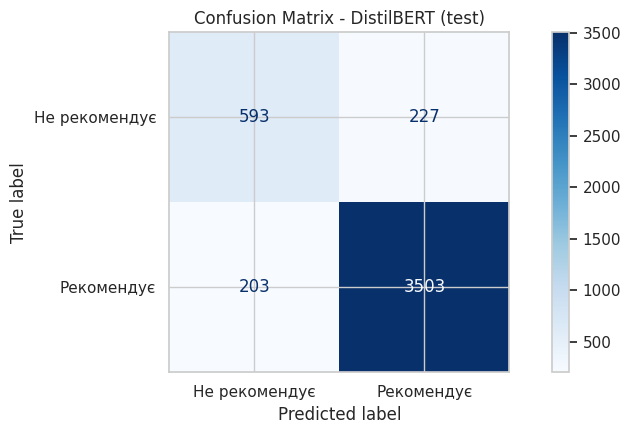

In [ ]:
test_predictions = trainer.predict(test_dataset)
logits = test_predictions.predictions
y_test_pred_bert = np.argmax(logits, axis=1)
y_test_proba_bert = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

cm = confusion_matrix(y_test, y_test_pred_bert)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Не рекомендує", "Рекомендує"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - DistilBERT (test)")
plt.tight_layout()
plt.show()

###висновок
з 820 реальних "не рекомендує" (593+227) модель правильно визначила лише 593, тобто помилилась у 227 випадках з 820 (десь 28%). Це помітно гірше, ніж для класу "рекомендує", де помилка лише 203 з 3706 (десь 5%).
Це прямий наслідок дисбалансу класів, бо прикладів "не рекомендує" значно менше в тренувальних даних.

Далі подивимось на конкретні приклади текстів, де модель помилилась (особливо False Positives - де вона пропустила невдоволення клієнта)

In [ ]:
# збираємо результати в датафрейм для аналізу
error_analysis = pd.DataFrame({
    "review_text": X_text_test.values,
    "true_label": y_test.values,
    "predicted_label": y_test_pred_bert,
    "predicted_proba": y_test_proba_bert
})

# текстова розшифровка міток
error_analysis["true_label_text"] = error_analysis["true_label"].map({0: "Не рекомендує", 1: "Рекомендує"})
error_analysis["predicted_label_text"] = error_analysis["predicted_label"].map({0: "Не рекомендує", 1: "Рекомендує"})

In [ ]:
# False Positive: модель сказала "рекомендує", а насправді "не рекомендує"
false_positives = error_analysis[
    (error_analysis["true_label"] == 0) & (error_analysis["predicted_label"] == 1)
]

print("=== False Positive: модель помилково вважає що клієнт рекомендує ===")
print(f"Кількість: {len(false_positives)}\n")

for idx, row in false_positives.head(5).iterrows():
    print(f"Справжня мітка: {row['true_label_text']}")
    print(f"Передбачена мітка: {row['predicted_label_text']}")
    print(f"Ймовірність 'рекомендує': {row['predicted_proba']:.3f}")
    print(f"Текст: {row['review_text'][:300]}")
    print("-" * 80)

=== False Positive: модель помилково вважає що клієнт рекомендує ===
Кількість: 227

Справжня мітка: Не рекомендує
Передбачена мітка: Рекомендує
Ймовірність 'рекомендує': 0.975
Текст: Whatever happened to sizing! pretty print and color but has enough fabric for 2 tops. it is also unlined which is not a huge issue. i wore it with a cami. the arms weren't too gaping for me, thankfully. i tried to make it work with a wide belt but i will have to get it tucked on the sides. i am 140 
--------------------------------------------------------------------------------
Справжня мітка: Не рекомендує
Передбачена мітка: Рекомендує
Ймовірність 'рекомендує': 0.903
Текст: I like the quality of material of this top but it's too long and wide for my frame. the high neck feels odd for my broad shoulders. too bad as i really wanted to love this.
--------------------------------------------------------------------------------
Справжня мітка: Не рекомендує
Передбачена мітка: Рекомендує
Ймовірність 'рекоменд

Аналіз помилок False Positive
Модель помиляється на відгуках, що починаються
з похвали, а негативний висновок з'являється лише в кінці тексту у вигляді
конкретної скарги або непрямого висновку.



In [ ]:
# False Negative: модель сказала "не рекомендує", а насправді "рекомендує"
false_negatives = error_analysis[
    (error_analysis["true_label"] == 1) & (error_analysis["predicted_label"] == 0)
]

print("=== False Negative: модель помилково вважає що клієнт НЕ рекомендує ===")
print(f"Кількість: {len(false_negatives)}\n")

for idx, row in false_negatives.head(5).iterrows():
    print(f"Справжня мітка: {row['true_label_text']}")
    print(f"Передбачена мітка: {row['predicted_label_text']}")
    print(f"Ймовірність 'рекомендує': {row['predicted_proba']:.3f}")
    print(f"Текст: {row['review_text'][:300]}")
    print("-" * 80)

=== False Negative: модель помилково вважає що клієнт НЕ рекомендує ===
Кількість: 203

Справжня мітка: Рекомендує
Передбачена мітка: Не рекомендує
Ймовірність 'рекомендує': 0.272
Текст: I think the shirt is supposed to be a relaxed  fit, but i could have definitely gone down a size
--------------------------------------------------------------------------------
Справжня мітка: Рекомендує
Передбачена мітка: Не рекомендує
Ймовірність 'рекомендує': 0.287
Текст: This shirt is adorable but it's really just a cotton t-shirt. based on the picture online, i thought it would have more weight, be a more substantial fabric. again, it's adorable but not sure how long it will last.
--------------------------------------------------------------------------------
Справжня мітка: Рекомендує
Передбачена мітка: Не рекомендує
Ймовірність 'рекомендує': 0.362
Текст: I saw this dress in my local retailer store, and am not sure why i did not try it on then, but later at home it began to haunt me. i loved th

Аналіз помилок False Negative підтверджує
дзеркальну закономірність до False Positive: клієнти хвалять товар на
початку відгуку, а потім описують практичну проблему
(розмір, посадка, довжина) - але попри це все одно рекомендують товар.

Модель чіпляється за негативний опис проблеми і помилково передбачає
"не рекомендує".

## Загальні висновки проєкту

**Задача:** передбачення чи рекомендує клієнт товар (`Recommended IND`) на основі
тексту відгуку та супутніх ознак (вік, категорія товару, кількість корисних
відміток тощо).

**Порівняння моделей (validation set):**

| Модель | F1-score | ROC-AUC |
|--------|----------|---------|
| Logistic Regression (baseline) | 0.9223 | 0.9430 |
| LightGBM | 0.9184 | 0.9279 |
| LightGBM + Optuna | 0.9329 | 0.9314 |
| Neural Network (Embedding) | 0.9184 | 0.9033 |
| **DistilBERT** | **0.9474** | **0.9568** |

**Фінальна оцінка обраної моделі (test set, одноразово):**

| Модель | F1-score | ROC-AUC |
|--------|----------|---------|
| **DistilBERT** | **0.9422** | **0.9526** |

**Найкраща модель - DistilBERT.** Вона впевнено перевершила усі інші підходи
по обох метриках на validation, і ця перевага підтвердилась на test set.
Це очікувано: на відміну від TF-IDF та Embedding-моделі з усередненням
векторів, DistilBERT розуміє контекст і порядок слів у реченні, що критично
важливо для відгуків із запереченнями та нюансами ("не сподобалось",
"трохи розчарував").

**Практичне застосування:** модель можна використати для автоматичного
пріоритезування відгуків - миттєво виявляти незадоволених клієнтів по тексту,
не чекаючи поки вони самі виставлять негативний рейтинг чи публічно
поскаржаться, і оперативно реагувати (запропонувати повернення, обмін,
компенсацію).

**Обмеження моделі:** аналіз помилок показав, що DistilBERT систематично
помиляється на **амбівалентних відгуках**, де похвала і критика присутні
одночасно (наприклад, клієнт хвалить дизайн, але не рекомендує через
проблему з розміром чи якістю тканини, або навпаки - критикує деталь,
але все одно рекомендує товар). У таких випадках модель орієнтується
на загальний емоційний тон окремих фраз, а не завжди коректно визначає,
яка частина відгуку є вирішальною для фінального рішення клієнта.

**Напрямки для покращення:**
- збільшити `max_length` токенізації з 100 до 200
- спробувати RoBERTa для потенційно кращого розуміння довгого контексту
- об'єднати передбачення DistilBERT з табличними ознаками в ансамбль